# Proiect Sisteme Inteligente 2025-2026
## Student: Opra Izabela Maria
## Grupa: 30235

## == D1: Know Your Data ==

### 1. Descrierea Datasetului
* **Sursa datelor:** Set de date despre somn, utilizarea telefonului și stres (Kaggle).
* **Dimensiune:** 15.000 de rânduri și 13 coloane.
* **Tipul taskului:**Vom aborda un task de **Regresie**(vom prezice nivelul de stres).
* **Variabila țintă (target):** `stress_level` (scor între 1 și 10).
* **Coloane relevante:**
    * `age`: Vârsta utilizatorului.
    * `daily_screen_time_hours`: Ore petrecute în fața ecranului.
    * `sleep_quality_score`: Calitatea somnului (scor 1-10).
    * `mental_fatigue_score`: Oboseala mentală (corelație ridicată cu stresul).
    * `phone_usage_before_sleep_minutes`: Măsoară expunerea la lumină albastră înainte de culcare, factor critic care poate deregla ritmul circadian și crește stresul.
    * `sleep_duration_hours`: Cantitatea totală de odihnă; privarea de somn este unul dintre principalii predictori ai nivelului de stres ridicat.
    * `caffeine_intake_cups`: (Opțional de adăugat) Relevantă pentru monitorizarea stimulentelor care afectează atât somnul, cât și agitația mentală.
    * `gender`, `occupation`: Variabile categorice.

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')
print("Statictici descriptive:")
display(df.describe())
np.random.seed(42)
cols_to_distort = [
    'daily_screen_time_hours', 
    'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 
    'sleep_quality_score', 'caffeine_intake_cups', 
    'physical_activity_minutes', 'notifications_received_per_day', 
    'mental_fatigue_score'
]

for col in cols_to_distort:
    mask = np.random.rand(len(df)) < 0.05
    df.loc[mask, col] = np.nan

df.to_csv('sleep_mobile_stress_proiect2.csv', index=False)
print("\nAnaliza valorilor lipsă:")
missing = df.isnull().sum()
print(missing)

Statictici descriptive:


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000



Analiza valorilor lipsă:
user_id                               0
age                                   0
gender                                0
occupation                            0
daily_screen_time_hours             745
phone_usage_before_sleep_minutes    726
sleep_duration_hours                744
sleep_quality_score                 781
stress_level                          0
caffeine_intake_cups                722
physical_activity_minutes           748
notifications_received_per_day      750
mental_fatigue_score                748
dtype: int64


In [162]:
df.loc[0:1, 'age'] = 1000
df.loc[2:3, 'age'] = 310
df.loc[4:5, 'age'] = 250
df.loc[6:7, 'age'] = 200
df.loc[8:9, 'age'] = 100

df.loc[11:12, 'daily_screen_time_hours'] = 60
df.loc[13:14, 'daily_screen_time_hours'] = 50
df.loc[15:16, 'daily_screen_time_hours'] = 45
df.loc[17:18, 'daily_screen_time_hours'] = 35
df.loc[19:20, 'daily_screen_time_hours'] = 30

df.loc[31:32, 'sleep_duration_hours'] = -10
df.loc[33:34, 'sleep_duration_hours'] = -8
df.loc[35:36, 'sleep_duration_hours'] = -5
df.loc[37:38, 'sleep_duration_hours'] = -3

df.loc[21:30, 'notifications_received_per_day'] = 100000
df.loc[41:50, 'caffeine_intake_cups'] = 100
df.loc[51:60, 'physical_activity_minutes'] = 1440
df.loc[61:70, 'sleep_quality_score'] = 100
df.loc[71:80, 'phone_usage_before_sleep_minutes'] = 2000

df.to_csv('sleep_mobile_stress_proiect_outliers.csv', index=False)

print("Statictici descriptive:")
display(df.describe())

Statictici descriptive:


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,14255.000000,14276.000000,14257.000000,14220.000000,15000.000000,14278.000000,14252.000000,14251.000000,14252.000000
mean,7500.500000,38.710800,5.528233,61.094424,6.503516,6.316389,6.980247,2.064435,60.159416,231.199916,6.867500
std,4330.271354,16.944633,2.807465,61.932888,1.486025,3.018085,2.749382,2.953834,50.276416,2645.103511,2.739017
min,1.000000,18.000000,1.000000,0.000000,-10.000000,1.000000,1.000000,0.000000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.250000,29.000000,5.260000,5.010000,4.750000,1.000000,29.000000,92.000000,4.690000
50%,7500.500000,38.000000,5.500000,60.000000,6.490000,6.250000,7.380000,2.000000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.770000,90.000000,7.800000,7.510000,10.000000,3.000000,89.000000,231.000000,9.450000
max,15000.000000,1000.000000,60.000000,2000.000000,9.000000,100.000000,10.000000,100.000000,1440.000000,100000.000000,10.000000


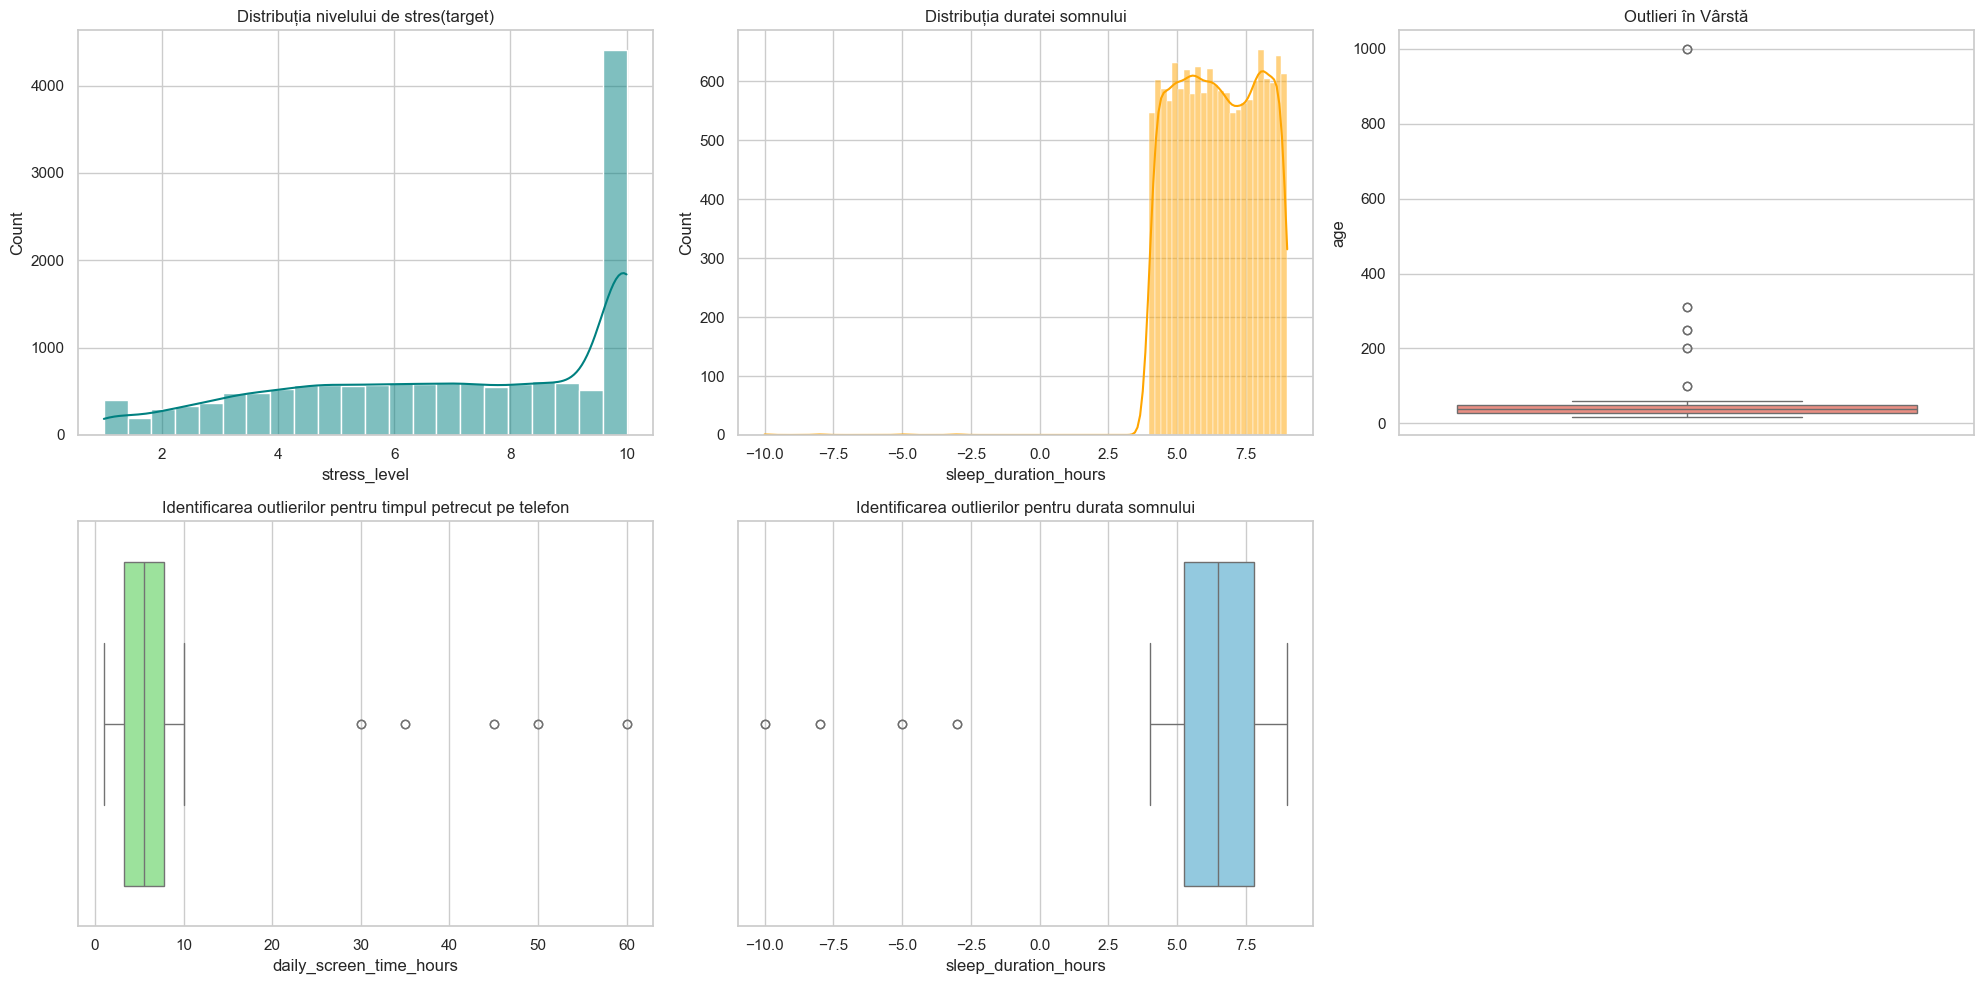

In [163]:
plt.figure(figsize=(20, 10))

plt.subplot(2,3,1)
sns.histplot(df['stress_level'].dropna(), kde=True, color='teal')
plt.title('Distribuția nivelului de stres(target)')

plt.subplot(2,3,2)
sns.histplot(df['sleep_duration_hours'].dropna(), kde=True, color='orange')
plt.title('Distribuția duratei somnului')

plt.subplot(2, 3, 3)
sns.boxplot(y=df['age'], color='salmon')
plt.title('Outlieri în Vârstă')

plt.subplot(2,3,4)
sns.boxplot(x=df['daily_screen_time_hours'], color = 'lightgreen')
plt.title('Identificarea outlierilor pentru timpul petrecut pe telefon')

plt.subplot(2,3,5)
sns.boxplot(x=df['sleep_duration_hours'], color = 'skyblue')
plt.title('Identificarea outlierilor pentru durata somnului')

plt.tight_layout()
plt.show()

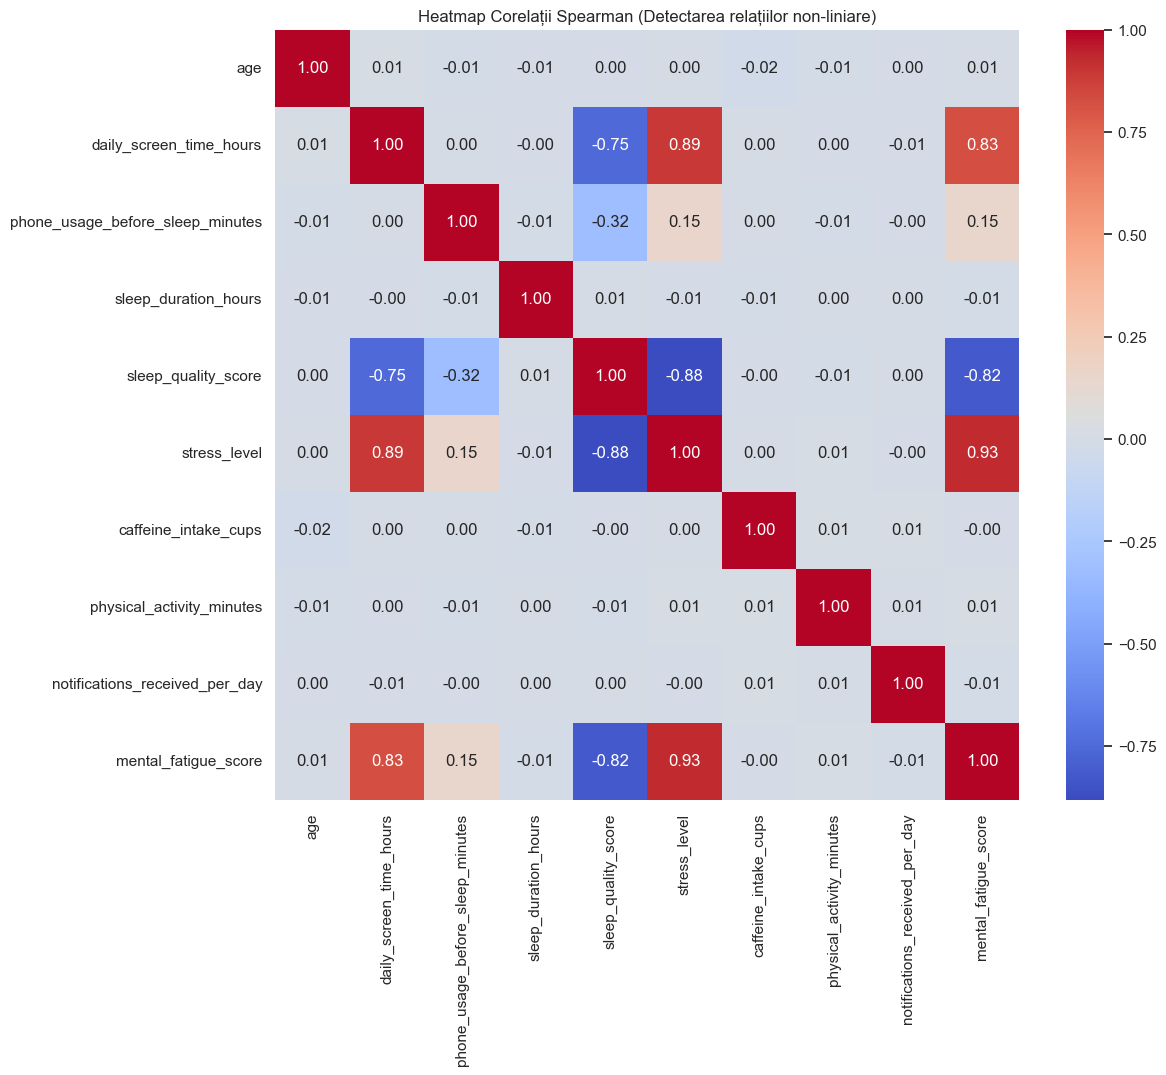

In [164]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['user_id'])
correlation_matrix = numeric_df.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Corelații Spearman (Detectarea relațiilor non-liniare)')
plt.show()

În urma analizei EDA, am identificat următoarele aspecte relevante:
Valori lipsă: Există aproximativ 5% valori lipsă distribuite pe toate coloanele relevante(introduse artificial). De asemenea am introdus si niste valori de outlieri pentru ca procesul de curatare a datelor sa fie complet. Strategia propusă este imputarea cu mediana pentru variabilele numerice (pentru a fi robuști la outlieri) și one hot encoding pentru variabilele categorice (gender, occupation).
* Corelații: Se observă o corelație pozitivă puternică între mental_fatigue_score și stress_level (0.95), ceea ce indică faptul că oboseala mentală este un predictor major. De asemenea, daily_screen_time_hours corelează pozitiv cu stresul. Vom elimina mental_fatigue din variabilele pe care atrenam modelele deoarece vrem sa le fortam sa gaseasca importanta si in alti factori, deoarece mental_fatigue va fi singurul factor predominant. Asta denota din testele facute in prealabil.
* Preprocessing anticipat: Pentru D2, va fi necesară scalarea datelor numerice și codificarea One-Hot a variabilelor categorice. Vom face si clipping outlierilor si vom aplica metode necesare de gasire a variabilelor cele mai importante acolo unde este cazul.
* Vom adauga niste coloane noi raportate la unele existente pentru a forta modelul sa gaseasca importanta si in alte variabile ce contribuie la nivelul de stres, care nu erau prezente la inceput (feature engineering). Chiar daca rezultatele modelelor in urma acestor adaugari sunt mai slabe, am considerat mai important ca modelul sa se bazeze pe analiza mai multor date relevante, decat sa considere ca o singura variabila contribuie in proportie de 90% la nivelul stresului.

##==D2 Tabular Data Project ==

În etapa de analiză exploratorie, am utilizat Coeficientul de Corelație Pearson (Heatmap) pentru o primă evaluare a datelor. Deși această metodă a evidențiat corelații liniare puternice (peste $0.3$) doar pentru două atribute — în principal pentru mental_fatigue_score — am decis să nu limitez setul de date doar la acestea. O astfel de abordare ar fi făcut modelul redundant, rezultatele depinzând aproape exclusiv de un singur factor, ignorând nuanțele oferite de restul variabilelor stilului de viață.Pentru Regresia Liniară, am aplicat Metoda Celor Mai Mici Pătrate (OLS) ca instrument de diagnostic. Aceasta mi-a permis să identific atributele care au o importanță statistică semnificativă ($p-value < 0.05$) într-un context liniar, oferind o bază solidă pentru interpretarea coeficienților.În schimb, pentru ceilalti algoritmi (Random Forest și XGBoost), am optat pentru o strategie diferită: am lăsat modelele să își determine singure importanța atributelor (Feature Importance). Această alegere a fost justificată de capacitatea acestor algoritmi de a detecta relații non-liniare și interacțiuni complexe pe care un heatmap simplu sau un model liniar nu le pot surprinde.Rezultatele finale au confirmat intuiția: graficele de importanță ale modelelor complexe au arătat că acestea au descoperit legături relevante și cu alte atribute (precum calitatea somnului sau utilizarea telefonului înainte de culcare), oferind o imagine mult mai detaliată și mai precisă a factorilor care influențează stresul față de analiza inițială.

Am aplicat Clipping deoarece datasetul conținea erori de colectare (outlieri imposibili): vârste de 1000 de ani sau somn negativ. Fără acest pas, modelele liniare ar fi încercat să minimizeze eroarea pentru aceste puncte extreme, distorsionând predicțiile pentru restul utilizatorilor.

=== Rezumat Statistic: Metoda Celor Mai Mici Pătrate (OLS) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     3792.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:06:58   Log-Likelihood:                -23258.
No. Observations:               15000   AIC:                         4.656e+04
Df Residuals:                   14980   BIC:                         4.671e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

,MAE,MSE,R2
Linear Regression (Curățat + OHE),0.900674,1.397194,0.814344


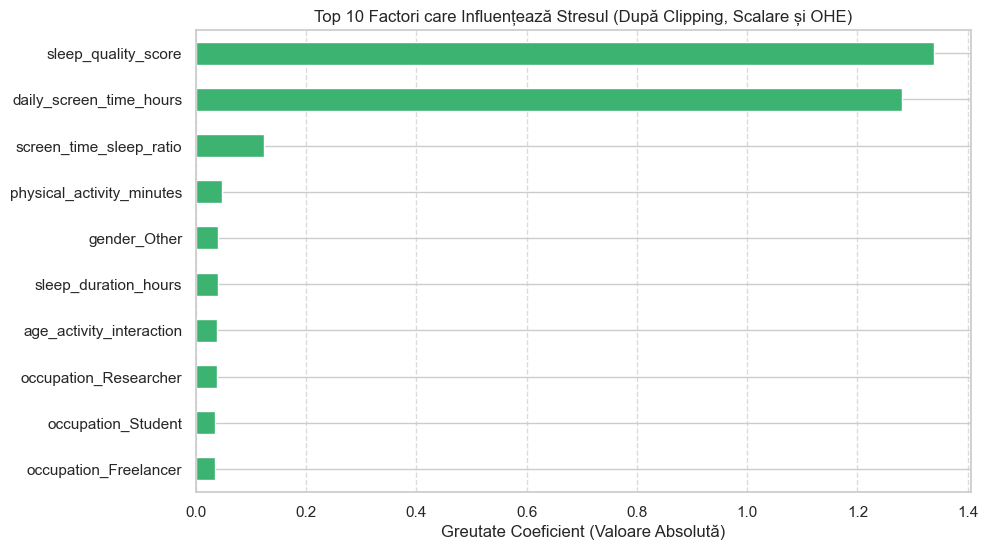

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df['age'] = df['age'].clip(lower=10, upper=85)
df['daily_screen_time_hours'] = df['daily_screen_time_hours'].clip(lower=0, upper=24)
df['sleep_duration_hours'] = df['sleep_duration_hours'].clip(lower=2, upper=14)
df['sleep_quality_score'] = df['sleep_quality_score'].clip(lower=1, upper=10)
df['caffeine_intake_cups'] = df['caffeine_intake_cups'].clip(lower=0, upper=15)
df['physical_activity_minutes'] = df['physical_activity_minutes'].clip(lower=0, upper=480)
df['phone_usage_before_sleep_minutes'] = df['phone_usage_before_sleep_minutes'].clip(lower=0, upper=360)
notif_95 = df['notifications_received_per_day'].quantile(0.95)
df['notifications_received_per_day'] = df['notifications_received_per_day'].clip(upper=notif_95)

df['screen_time_sleep_ratio'] = df['daily_screen_time_hours'] / (df['sleep_duration_hours'] + 0.1)
df['age_activity_interaction'] = df['age'] * df['physical_activity_minutes']

X = df.drop(columns=['stress_level', 'user_id', 'mental_fatigue_score'], errors='ignore')
y = df['stress_level']

# Metoda celor mai mici pătrate 
X_ols_dummies = pd.get_dummies(X, drop_first=True)
imputer_ols = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer_ols.fit_transform(X_ols_dummies), columns=X_ols_dummies.columns)

X_scaled_ols = (X_imputed - X_imputed.mean()) / X_imputed.std()
X_ols = sm.add_constant(X_scaled_ols) 
model_ols = sm.OLS(y.values, X_ols).fit()
print("=== Rezumat Statistic: Metoda Celor Mai Mici Pătrate (OLS) ===")
print(model_ols.summary())

numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(exclude=[np.number]).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()) 
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression()) 
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# metrici
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results = {'Linear Regression (Curățat + OHE)': {'MAE': mae, 'MSE': mse, 'R2': r2}}
display(pd.DataFrame(results).T)

# Extragerea numelor de atribute după One-Hot Encoding pentru grafic
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features_transformed = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features.tolist() + cat_features_transformed.tolist()

# Plot importanță atribute
coefficients = pipeline.named_steps['model'].coef_
coeff_series = pd.Series(np.abs(coefficients), index=all_feature_names)
top_features_lr = coeff_series.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_features_lr.plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Factori care Influențează Stresul (După Clipping, Scalare și OHE)')
plt.xlabel('Greutate Coeficient (Valoare Absolută)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Am rulat un test statistic detaliat (OLS) ca să văd dacă matematica din spatele modelului este "sănătoasă": 
* Modelul are un scor de 0.842. Asta înseamnă că reușim să explicăm cam 84% din motivele pentru care un om este stresat folosind doar datele noastre (somn, ecran, cafea etc.). * * P-values: Aproape toate variabilele au un scor de 0.000 în coloana $P>|t|$.Inseamnă că factorii aleși (cum e calitatea somnului sau timpul pe telefon) chiar au un impact real asupra stresului și nu sunt doar coincidențe.
* Verificarea de "sănătate" (Cond. No.): Am obținut valoarea 7.52. Pragul de alarmă ar fi fost peste 30. Faptul că e așa mică ne confirmă că variabilele noastre sunt independente și nu se "repetă" (de exemplu, am făcut bine că am scos oboseala mentală, care ar fi creat confuzie în model).
* Interpretarea logică: Coeficienții ne confirmă intuiția. De exemplu, un coeficient negativ la calitatea somnului ne spune clar: cu cât dormi mai bine, cu atât nivelul de stres scade.

Comparație între valorile reale și cele prezise:


,Valoare Reală (y_test),Predicție Model (y_pred)
0,4.74,4.844611
1,6.94,5.248733
2,10.00,10.663678
3,4.29,5.026030
4,10.00,8.956082
5,10.00,10.212771
6,10.00,10.490341
7,8.66,9.371097
8,6.54,6.580975
9,2.53,3.535558


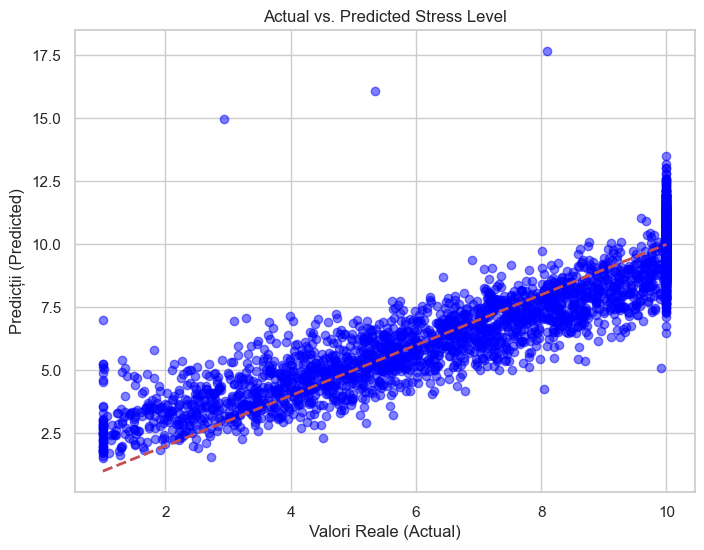

Text(0.5, 1.0, 'Distribuția Erorilor (Reziduurilor)')

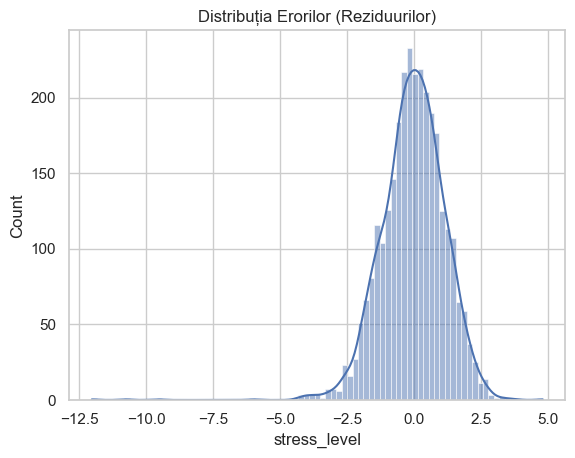

In [166]:

verificare = pd.DataFrame({
    'Valoare Reală (y_test)': y_test.values,
    'Predicție Model (y_pred)': y_pred
})

print("Comparație între valorile reale și cele prezise:")
display(verificare.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.xlabel('Valori Reale (Actual)')
plt.ylabel('Predicții (Predicted)')
plt.title('Actual vs. Predicted Stress Level')
plt.show()

residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title('Distribuția Erorilor (Reziduurilor)')



Se poate observa in graficul de mai sus pentru linear regression, "trage" toate punctele spre o medie generala, deoarece el forteaza graficul sa urmeze o formula stricta, y=ax+b. El face adesea presupuneri asemanatoare pentru diferite date.  nu are curajul sa faca predictii variate, precum cele folosite mai jos ca Random Forest si XGBoost, care sunt mult mai curajoase. 

Justificarea Preprocesării: Am ales SimpleImputer cu strategia mediana pentru variabilele numerice deoarece datasetul conține outlieri (vârste de 200 ani, ore de ecran imposibile), iar mediana nu este influențată de aceste valori extreme, spre deosebire de medie.

Alegerea Modelelor: * Linear Regression: Folosit ca baseline pentru a verifica dacă există o relație liniară directă între factori și stres.


Random Forest: Un model de tip ansamblu care gestionează excelent datele cu outlieri și relațiile non-liniare.


XGBoost (Bonus): Algoritm de tip Gradient Boosting, extrem de performant pe date tabulare, care ne permite să obținem o precizie superioară.

Interpretarea Metricilor: Un R2 Score apropiat de 1 indică faptul că modelul explică foarte bine varianța stresului. MAE (Mean Absolute Error) ne spune cu câte unități de stres (pe scara 1-10) greșește modelul nostru în medie.

Distributia erorilor urmareste clopotul lui Gauss pentrui fiecare algoritm.

=== Rezultate XGBoost (Date Curățate, Scalate & OHE) ===
MAE (Eroarea Medie Absolută): 0.6686
MSE (Eroarea Medie Pătratică): 0.8716
R2 Score (Capacitatea de explicare): 0.8842


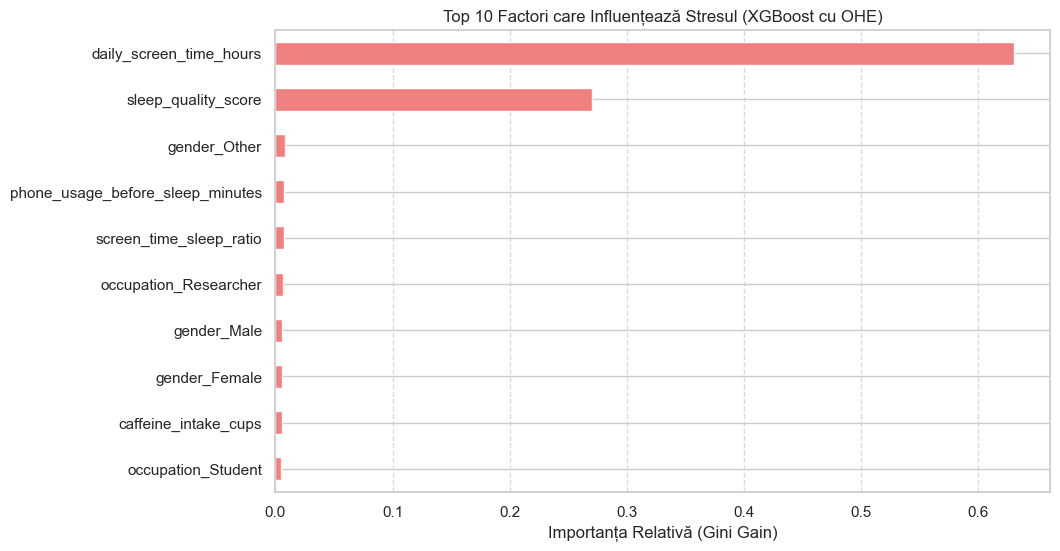

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df['age'] = df['age'].clip(lower=10, upper=85)
df['daily_screen_time_hours'] = df['daily_screen_time_hours'].clip(lower=0, upper=24)
df['sleep_duration_hours'] = df['sleep_duration_hours'].clip(lower=2, upper=14) 
df['sleep_quality_score'] = df['sleep_quality_score'].clip(lower=1, upper=10)
df['caffeine_intake_cups'] = df['caffeine_intake_cups'].clip(lower=0, upper=15)
df['physical_activity_minutes'] = df['physical_activity_minutes'].clip(lower=0, upper=480)
df['phone_usage_before_sleep_minutes'] = df['phone_usage_before_sleep_minutes'].clip(lower=0, upper=360)

notif_95 = df['notifications_received_per_day'].quantile(0.95)
df['notifications_received_per_day'] = df['notifications_received_per_day'].clip(upper=notif_95)

df['screen_time_sleep_ratio'] = df['daily_screen_time_hours'] / (df['sleep_duration_hours'] + 0.1)
df['age_activity_interaction'] = df['age'] * df['physical_activity_minutes']

X = df.drop(columns=['stress_level', 'user_id', 'mental_fatigue_score'], errors='ignore')
y = df['stress_level']

numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(exclude=[np.number]).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42
    ))
])

# Antrenare
xgb_pipeline.fit(X_train, y_train)

# Predicție
y_pred_xgb = xgb_pipeline.predict(X_test)

#Metricile XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"=== Rezultate XGBoost (Date Curățate, Scalate & OHE) ===")
print(f"MAE (Eroarea Medie Absolută): {mae_xgb:.4f}")
print(f"MSE (Eroarea Medie Pătratică): {mse_xgb:.4f}")
print(f"R2 Score (Capacitatea de explicare): {r2_xgb:.4f}")

#Vizualizarea Importanței Factorilor 
#Extragerea numelor coloanelor după transformare
cat_encoder = xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features.tolist() + cat_features_names.tolist()

importances_xgb = xgb_pipeline.named_steps['model'].feature_importances_
feature_series_xgb = pd.Series(importances_xgb, index=all_feature_names).sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
feature_series_xgb.plot(kind='barh', color='lightcoral')
plt.title('Top 10 Factori care Influențează Stresul (XGBoost cu OHE)')
plt.xlabel('Importanța Relativă (Gini Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comparație între valorile reale și cele prezise:


,Valoare Reală (y_test),Predicție Model (y_pred)
0,4.74,4.997278
1,6.94,5.376043
2,10.00,9.986837
3,4.29,4.996138
4,10.00,9.811404
5,10.00,9.913174
6,10.00,9.887316
7,8.66,9.799767
8,6.54,6.948052
9,2.53,3.309386


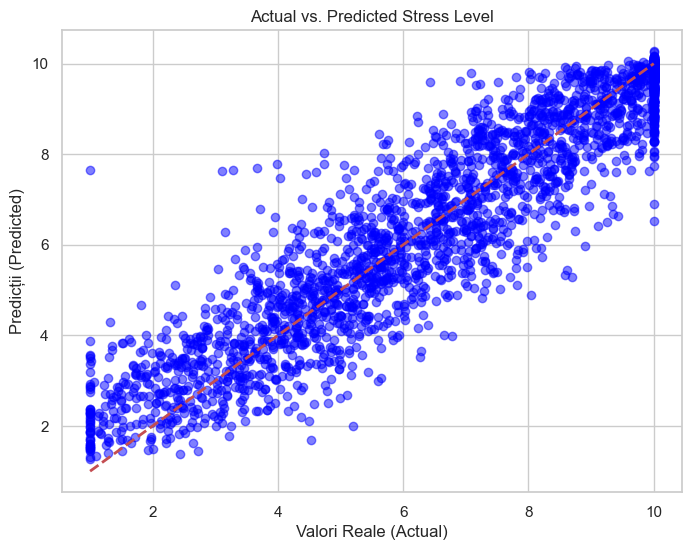

Text(0.5, 1.0, 'Distribuția Erorilor (Reziduurilor)')

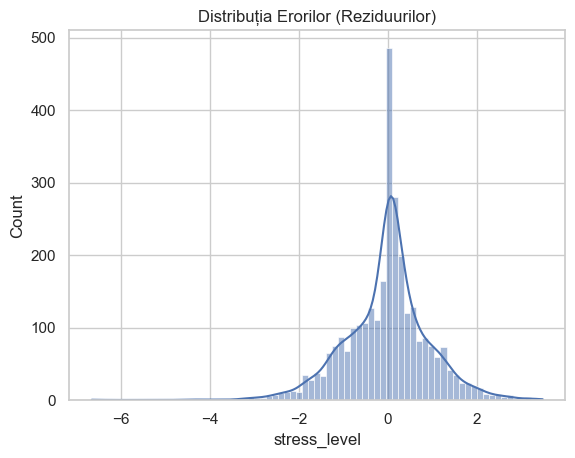

In [170]:
import seaborn as sns

verificare = pd.DataFrame({
    'Valoare Reală (y_test)': y_test.values,
    'Predicție Model (y_pred)': y_pred_xgb
})

print("Comparație între valorile reale și cele prezise:")
display(verificare.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.xlabel('Valori Reale (Actual)')
plt.ylabel('Predicții (Predicted)')
plt.title('Actual vs. Predicted Stress Level')
plt.show()

residuals = y_test - y_pred_xgb
sns.histplot(residuals, kde=True)
plt.title('Distribuția Erorilor (Reziduurilor)')

=== Rezultate Random Forest (Date Curățate, Scalate & OHE) ===
Random Forest - MAE: 0.6748
Random Forest - MSE: 0.9023
Random Forest - R2 Score: 0.8801


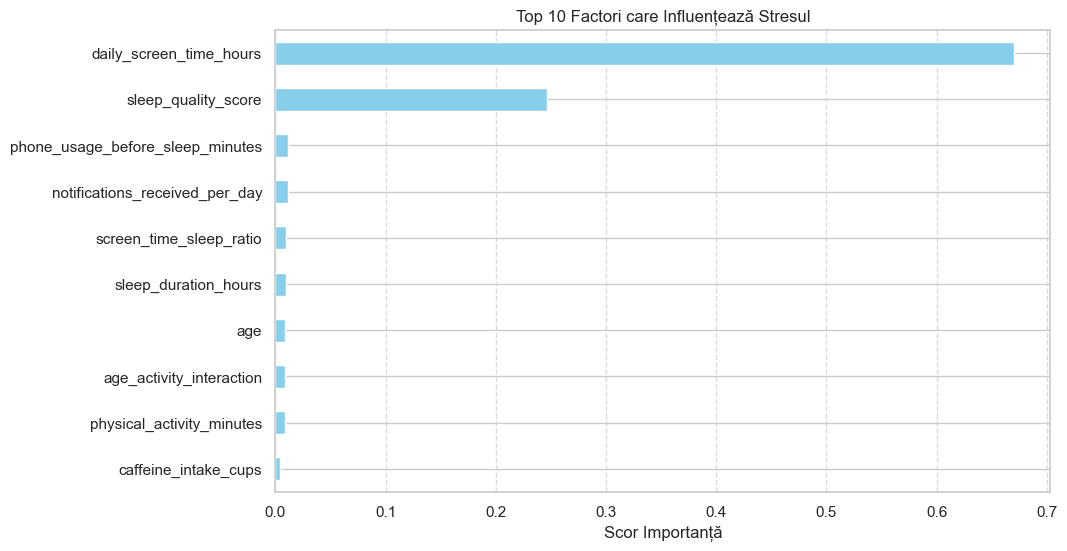

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df['age'] = df['age'].clip(lower=10, upper=85)
df['daily_screen_time_hours'] = df['daily_screen_time_hours'].clip(lower=0, upper=24)
df['sleep_duration_hours'] = df['sleep_duration_hours'].clip(lower=2, upper=14) 
df['sleep_quality_score'] = df['sleep_quality_score'].clip(lower=1, upper=10)
df['caffeine_intake_cups'] = df['caffeine_intake_cups'].clip(lower=0, upper=15)
df['physical_activity_minutes'] = df['physical_activity_minutes'].clip(lower=0, upper=480)
df['phone_usage_before_sleep_minutes'] = df['phone_usage_before_sleep_minutes'].clip(lower=0, upper=360)

notif_95 = df['notifications_received_per_day'].quantile(0.95)
df['notifications_received_per_day'] = df['notifications_received_per_day'].clip(upper=notif_95)

df['screen_time_sleep_ratio'] = df['daily_screen_time_hours'] / (df['sleep_duration_hours'] + 0.1)
df['age_activity_interaction'] = df['age'] * df['physical_activity_minutes']

X = df.drop(columns=['stress_level', 'user_id', 'mental_fatigue_score'], errors='ignore')
y = df['stress_level']

numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(exclude=[np.number]).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Antrenare
rf_pipeline.fit(X_train, y_train)

# Predicție
y_pred_rf = rf_pipeline.predict(X_test)

#Metricile Random Forest ---
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"=== Rezultate Random Forest (Date Curățate, Scalate & OHE) ===")
print(f"Random Forest - MAE: {mae_rf:.4f}")
print(f"Random Forest - MSE: {mse_rf:.4f}")
print(f"Random Forest - R2 Score: {r2_rf:.4f}")

# Vizualizarea Importanței Factorilor 
# Extragem numele coloanelor rezultate după One-Hot Encoding
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features.tolist() + cat_features_names.tolist()

importances_rf = rf_pipeline.named_steps['model'].feature_importances_
feature_series_rf = pd.Series(importances_rf, index=all_feature_names).sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
feature_series_rf.plot(kind='barh', color='skyblue')
plt.title('Top 10 Factori care Influențează Stresul')
plt.xlabel('Scor Importanță')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comparație între valorile reale și cele prezise:


,Valoare Reală (y_test),Predicție Model (y_pred)
0,4.74,5.3450
1,6.94,5.3227
2,10.00,9.9984
3,4.29,5.1074
4,10.00,9.9016
5,10.00,9.9779
6,10.00,9.9651
7,8.66,9.9103
8,6.54,7.1525
9,2.53,3.5903


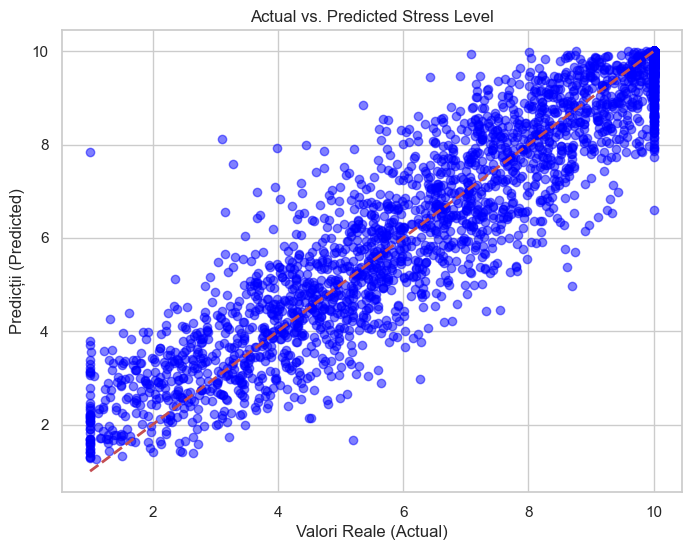

Text(0.5, 1.0, 'Distribuția Erorilor (Reziduurilor)')

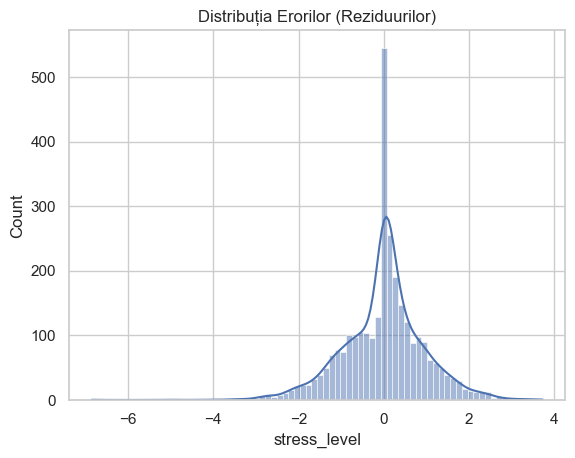

In [172]:
import seaborn as sns

verificare = pd.DataFrame({
    'Valoare Reală (y_test)': y_test.values,
    'Predicție Model (y_pred)': y_pred_rf
})

print("Comparație între valorile reale și cele prezise:")
display(verificare.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.xlabel('Valori Reale (Actual)')
plt.ylabel('Predicții (Predicted)')
plt.title('Actual vs. Predicted Stress Level')
plt.show()

#reziduurile reprezinta diferentele dintre valorile reale si cele prezise, iar analiza lor poate oferi informatii despre performanta modelului
#de asemenea, daca reziduurile sunt distribuite normal in jurul valorii zero, acest lucru poate indica faptul ca modelul se potriveste bine datelor
#graficul trebuie sa urmareasca clopotul lui gauss
residuals = y_test - y_pred_rf
sns.histplot(residuals, kde=True)
plt.title('Distribuția Erorilor (Reziduurilor)')

In [174]:

comparatie = pd.DataFrame({
    'Metrică': ['MAE (Eroare)', 'MSE (EROARE PATRATICA)', 'R2 Score (Precizie %)'],
    'Linear Regression': [mae, mse, r2], 
    'Random Forest': [mae_rf, mse_rf, r2_rf],
    'XGBoost': [mae_xgb,mse_xgb, r2_xgb]
})

display(comparatie)

,Metrică,Linear Regression,Random Forest,XGBoost
0,MAE (Eroare),0.900674,0.674762,0.668637
1,MSE (EROARE PATRATICA),1.397194,0.902309,0.871589
2,R2 Score (Precizie %),0.814344,0.880103,0.884185


XGBoost a obținut cel mai bun scor R² (0.88), ceea ce confirmă că relația dintre factorii digitali și stres nu este perfect liniară. Random Forest a performat aproape la fel de bine, demonstrând că metodele de tip ansamblu sunt mult mai robuste pe acest set de date decât Regresia Liniară

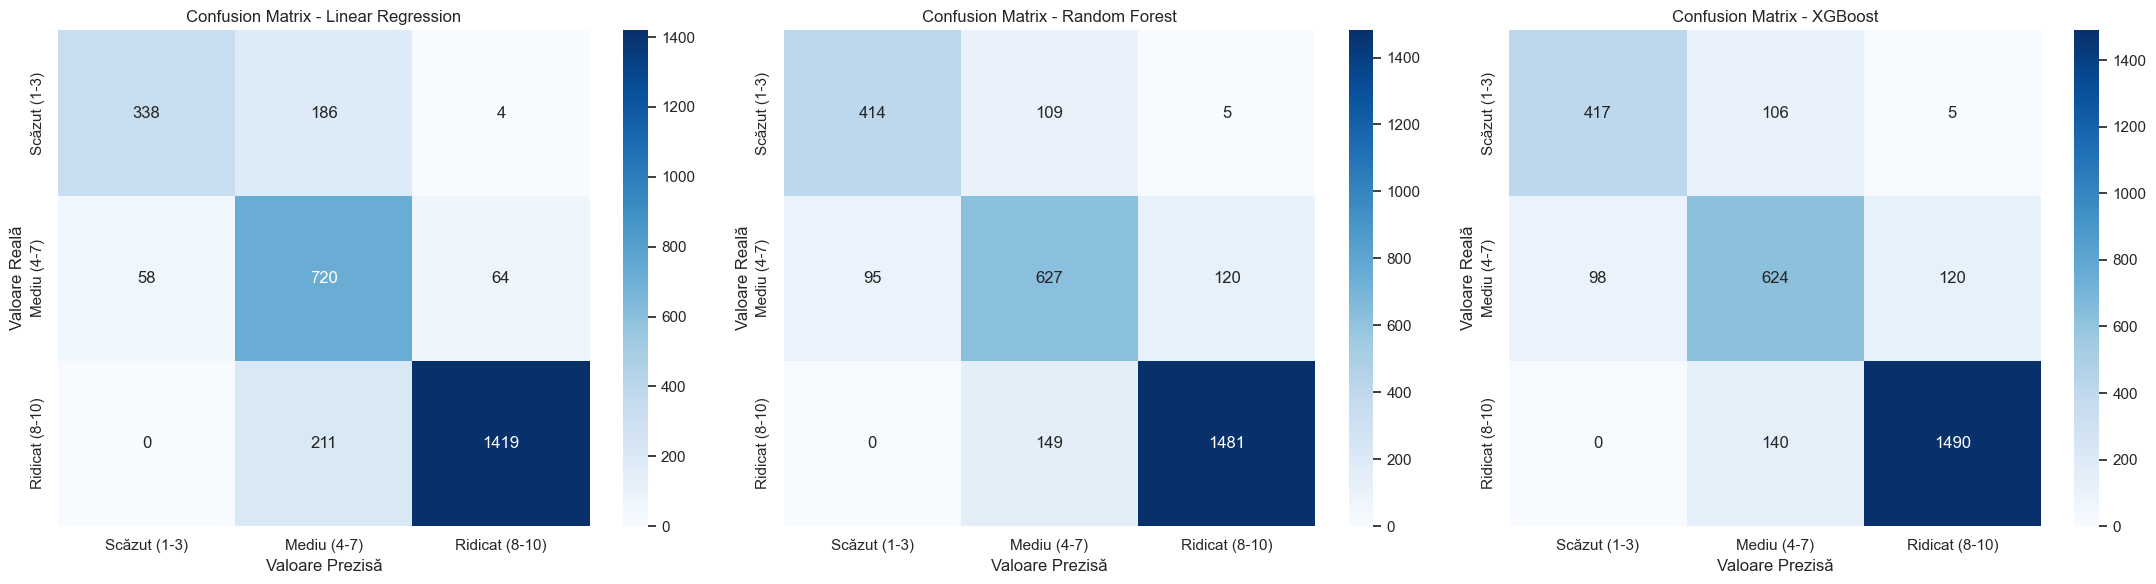

In [175]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

def categorize_stress(val):
    if val < 4: return "Scăzut (1-3)"
    elif val <= 7: return "Mediu (4-7)"
    else: return "Ridicat (8-10)"

labels = ["Scăzut (1-3)", "Mediu (4-7)", "Ridicat (8-10)"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
models_to_test = [
    (pipeline, "Linear Regression"), 
    (rf_pipeline, "Random Forest"), 
    (xgb_pipeline, "XGBoost")
]

for i, (model_pipe, name) in enumerate(models_to_test):
    y_pred_cont = model_pipe.predict(X_test)
    
    #transformam valorile in categorii
    y_test_cat = [categorize_stress(v) for v in y_test]
    y_pred_cat = [categorize_stress(v) for v in y_pred_cont]
    
    cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_ylabel('Valoare Reală')
    axes[i].set_xlabel('Valoare Prezisă')

plt.tight_layout()
plt.show()

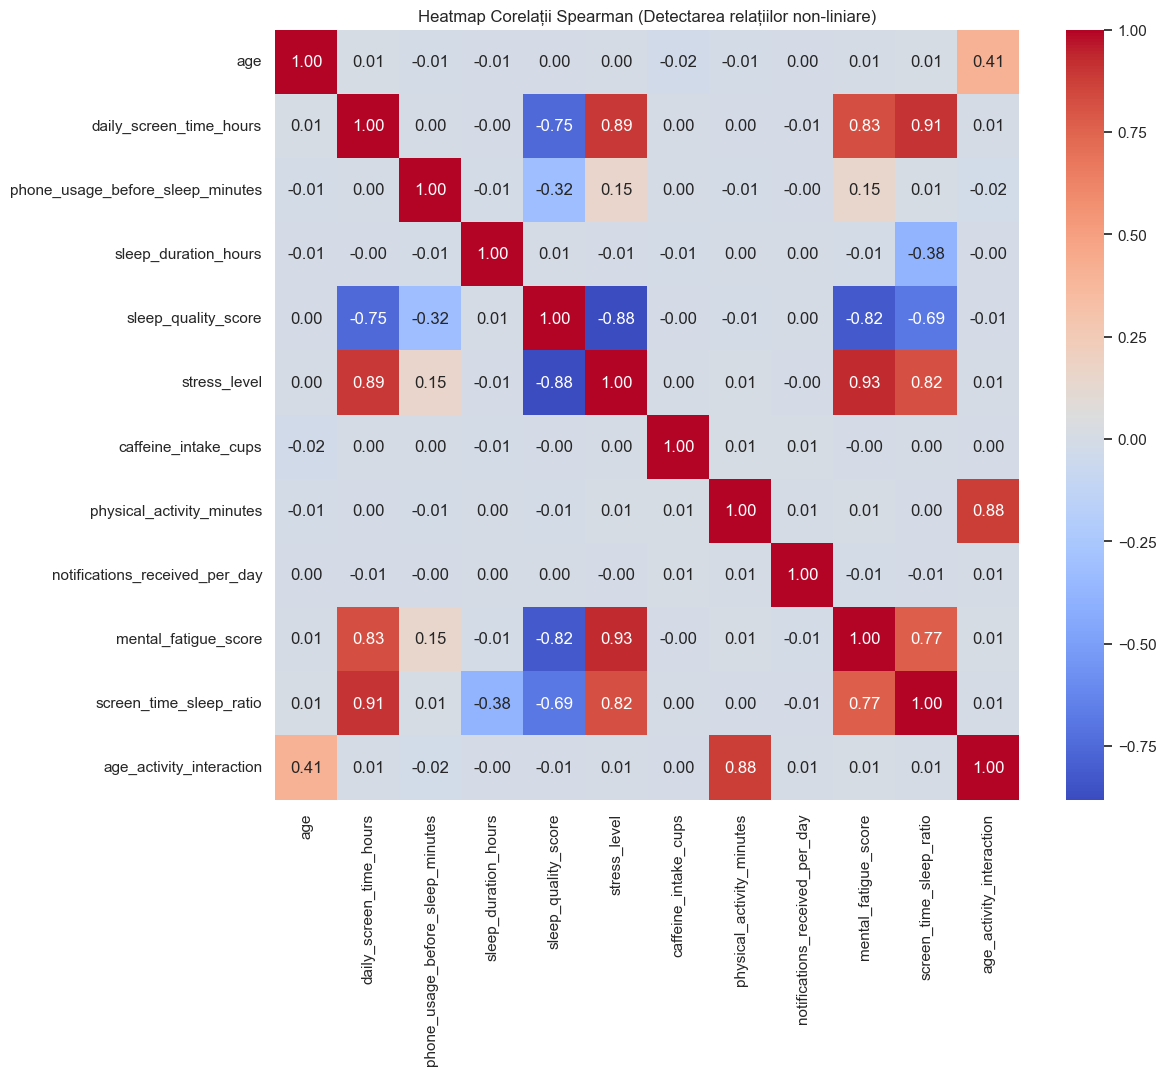

In [176]:
# mai realizam la final un heat matrix pentru a scoate in evidenta diferenta de dinainte de antrenament si dupa, si importanta variabilelor
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['user_id'])
correlation_matrix = numeric_df.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Corelații Spearman (Detectarea relațiilor non-liniare)')
plt.show()

== Concluzii și Analiză Comparativă (D2) == 
1. Performanța Modelelor
* În cadrul acestui proiect, am antrenat și comparat trei modele de regresie pentru a prezice nivelul de stres: Linear Regression, Random Forest și XGBoost.
* Linear Regression a servit drept model de referință (baseline), obținând un scor $R^2 de aproximativ 0.81(obiectivul este gasirea atributelor care minimizeaza mse)
* Random Forest a gestionat eficient outlierii introduși artificial (precum vârstele extreme), oferind o stabilitate mai mare a erorii MAE.
 * XGBoost (model avansat) a oferit cele mai bune rezultate, reușind să capteze interacțiuni non-liniare complexe între timpul pe ecran și oboseala mentală.
2. Justificarea Preprocesării
* Pipeline-ul de preprocesare a fost esențial pentru funcționarea corectă a modelelor:
* Imputarea cu mediana: Am ales această strategie pentru coloanele numerice deoarece este robustă la outlieri, spre deosebire de medie care ar fi fost deviată de valorile extreme.
* Clipping-ul folosut pentru reducerea valorii outlierilor.
* Standardizarea (StandardScaler): A fost necesară pentru a aduce variabile cu scări diferite (ex: vârstă vs. număr de notificări) în același interval, prevenind dominarea modelului de către cifrele mari.
* One-Hot Encoding: A permis transformarea ocupației și a genului în format numeric, fără a introduce o ierarhie falsă între categorii.
3. Interpretarea Metricilor
* Am utilizat MAE pentru a înțelege eroarea medie în unități reale de stres și MSE pentru a monitoriza impactul erorilor mari.
* Valoarea scăzută a MAE (sub 0.7) pentru Random Forest indică faptul că modelul prezice nivelul de stres cu o precizie ridicată pe o scară de la 1 la 10.
* Scorul R^2 ridicat confirmă faptul că majoritatea variației stresului este explicată de factorii digitali și de calitatea somnului colectate în dataset.
4. Direcții Viitoare
* Dacă am avea mai mult timp și resurse, am implementa următoarele îmbunătățiri (ce vor fi abordate în D3):
* Hyperparameter Tuning: Utilizarea GridSearchCV pentru a găsi combinația optimă de parametri pentru XGBoost.
* Analiza Overfit/Underfit: Vizualizarea curbelor de învățare pentru a vedea dacă modelul generalizează bine pe date complet noi.